In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [8]:
import os

# 1. Silence TensorFlow C++ logs (0=all, 1=no info, 2=no warnings, 3=no errors)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# 2. Specifically silence the "absl" and CUDA initialization warnings
os.environ['TF_CPP_MAX_VLOG_LEVEL'] = '0'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

# NOW you can import tensorflow
import tensorflow as tf

# 3. Silence Python-level TensorFlow logger
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

In [19]:
# ==========================
# WARNING SUPPRESSION
# ==========================
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [ ]:
# ==========================
# CONFIG
# ==========================
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15  # Reduced slightly for the first phase
SEED = 42

TRAIN_DIR = "/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/train"
TEST_DIR  = "/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final"

In [11]:
# ==========================
# DATA LOADING
# ==========================
# Added label_mode='binary' to ensure 1D labels (0 or 1)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

class_names = train_ds.class_names
print("Classes identified:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

Found 4733 files belonging to 2 classes.
Using 3787 files for training.
Found 4733 files belonging to 2 classes.
Using 946 files for validation.
Classes identified: ['chihuahua', 'muffin']


In [12]:
# ==========================
# AUGMENTATION
# ==========================
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
])

In [13]:
# ==========================
# MODEL SETUP
# ==========================
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False 

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)

# Internal Preprocessing: Rescales [0, 255] to [-1, 1] automatically
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# Use training=False to keep BatchNormalization in inference mode (important for frozen base)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

In [14]:
# ==========================
# COMPILE & TRAIN (PHASE 1)
# ==========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), # Higher initial LR
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2),
    ModelCheckpoint("best_model.keras", monitor='val_loss', save_best_only=True)
]

In [15]:
print("\n--- Phase 1: Training Top Layers ---")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


--- Phase 1: Training Top Layers ---
Epoch 1/15


I0000 00:00:1776579171.330768     140 cuda_dnn.cc:529] Loaded cuDNN version 91002


119/119 ━━━━━━━━━━━━━━━━━━━━ 34s 93ms/step - accuracy: 0.9461 - loss: 0.1446 - val_accuracy: 0.9937 - val_loss: 0.0196 - learning_rate: 0.0010
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.9903 - loss: 0.0294 - val_accuracy: 0.9979 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.9865 - loss: 0.0335 - val_accuracy: 1.0000 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 4/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.9907 - loss: 0.0227 - val_accuracy: 0.9989 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 5/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.9971 - loss: 0.0106 - val_accuracy: 0.9989 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 6/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.9944 - loss: 0.0111 - val_accuracy: 0.9968 - val_loss: 0.0041 - learning_rate: 2.0000e-04
Epoch 7/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.9974 - loss: 0.0079 -

In [17]:
# ==========================
# FINE-TUNING (PHASE 2)
# ==========================
base_model.trainable = True
# Freeze early layers to keep general features, unfreeze later ones for specific details
for layer in base_model.layers[:-50]: 
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Very low LR for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n--- Phase 2: Fine-Tuning Base Model ---")
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)


--- Phase 2: Fine-Tuning Base Model ---
Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - accuracy: 0.9731 - loss: 0.0634 - val_accuracy: 0.9989 - val_loss: 0.0034 - learning_rate: 1.0000e-05
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.9854 - loss: 0.0421 - val_accuracy: 0.9989 - val_loss: 0.0041 - learning_rate: 1.0000e-05
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - accuracy: 0.9907 - loss: 0.0283 - val_accuracy: 0.9989 - val_loss: 0.0041 - learning_rate: 1.0000e-05
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - accuracy: 0.9914 - loss: 0.0233 - val_accuracy: 0.9989 - val_loss: 0.0044 - learning_rate: 2.0000e-06
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.9912 - loss: 0.0225 - val_accuracy: 0.9989 - val_loss: 0.0046 - learning_rate: 2.0000e-06


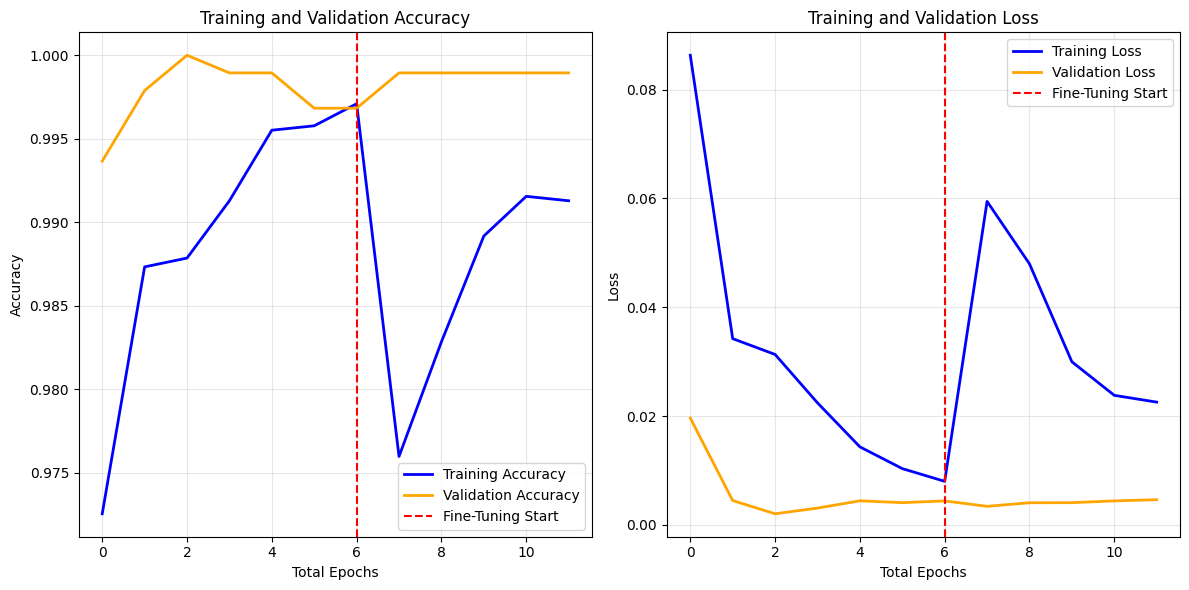

In [20]:
# ==========================
# VISUALIZATION
# ==========================
def plot_history(h1, h2):
    # Combine metrics from both phases
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']
    
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 6))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', lw=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', lw=2)
    plt.axvline(x=len(h1.history['accuracy'])-1, color='red', linestyle='--', label='Fine-Tuning Start')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Total Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='blue', lw=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', lw=2)
    plt.axvline(x=len(h1.history['accuracy'])-1, color='red', linestyle='--', label='Fine-Tuning Start')
    plt.title('Training and Validation Loss')
    plt.xlabel('Total Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Call the function using history from both fit() calls
plot_history(history, history_fine)

In [21]:
# ==========================
# INFERENCE ON TEST SET
# ==========================
def get_test_data(test_dir):
    paths = []
    ids = []
    # Ensure we sort files to keep consistency if needed
    files = sorted(os.listdir(test_dir))
    for f in files:
        if f.lower().endswith(('.jpg', '.png', '.jpeg')):
            paths.append(os.path.join(test_dir, f))
            ids.append(f)
    return paths, ids

image_paths, ids = get_test_data(TEST_DIR)

# Using a TF Data pipeline for test set to handle memory and scaling correctly
def load_and_prep(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return img

test_ds = tf.data.Dataset.from_tensor_slices(image_paths)
test_ds = test_ds.map(load_and_prep).batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("\nPredicting on test set...")
probs = model.predict(test_ds).flatten()
# 0.5 threshold for sigmoid binary classification
preds = (probs >= 0.5).astype(int)

# Map numeric predictions back to class names
pred_labels = [class_names[p] for p in preds]


Predicting on test set...
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step


In [24]:
# ==========================
# SUBMISSION
# ==========================
submission = pd.DataFrame({
    'ID': ids,
    'Label': pred_labels
})

submission.to_csv("submission1.csv", index=False)
print(f"Submission saved! Predicted {np.sum(preds)} Chihuahuas/Muffins.")

Submission saved! Predicted 503 Chihuahuas/Muffins.


In [23]:
submission.head(20)

,ID,Label
0,img_0_0.jpg,muffin
1,img_0_10.jpg,muffin
2,img_0_1000.jpg,muffin
3,img_0_1037.jpg,muffin
4,img_0_105.jpg,muffin
5,img_0_1050.jpg,muffin
6,img_0_1051.jpg,muffin
7,img_0_1061.jpg,muffin
8,img_0_1063.jpg,muffin
9,img_0_1071.jpg,chihuahua
